# Capstone Project: Klasifikasi Hypertrophic Scars vs Keloid Scars
### Deep Learning untuk Diagnosis Otomatis Bekas Luka Kulit

In [1]:
!pip install tensorflow opencv-python scikit-learn seaborn plotly fpdf2 tqdm -q

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')
%matplotlib inline

print("Import selesai!")


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import selesai!


In [2]:
# === KONFIGURASI ===
CLEAN_DIR = Path("dataset/Dataset_Bersih")
RAW_DIR = Path("dataset/Dataset_Mentah")
OUTPUT_DIR = Path("output")
PLOTS_DIR = OUTPUT_DIR / "plots"
MODELS_DIR = OUTPUT_DIR / "models"
METRICS_DIR = OUTPUT_DIR / "metrics"

CLASSES = {"hypertrophic scars": 0, "keloid scars": 1}
CLASS_NAMES = ["Hypertrophic", "Keloid"]
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
VALID_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")

for d in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def list_images(folder):
    if not folder.exists(): return []
    return [f for f in folder.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXT]

def load_image(path, size=IMG_SIZE):
    img = cv2.imread(str(path))
    if img is None: return None
    return cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (size, size))

# Verifikasi path
print(f"RAW exists: {RAW_DIR.exists()} | CLEAN exists: {CLEAN_DIR.exists()}")
print("Konfigurasi siap!")


RAW exists: True | CLEAN exists: True
Konfigurasi siap!


# TASK 2: Data Wrangling End-to-End
## Gathering, Assessing, dan Cleaning Data

In [3]:
print("=" * 60)
print("TASK 2: DATA WRANGLING")
print("=" * 60)

assessment = {}
for cls_name, cls_label in CLASSES.items():
    raw_imgs = list_images(RAW_DIR / cls_name)
    clean_imgs = list_images(CLEAN_DIR / cls_name / "sukses_diproses")
    blur_imgs = list_images(CLEAN_DIR / cls_name / "dibuang_karena_blur")

    sizes, sharpness_vals, brightness_vals = [], [], []
    for img_path in tqdm(clean_imgs[:50], desc=f"Analyzing {cls_name}"):
        img = cv2.imread(str(img_path))
        if img is not None:
            sizes.append(img_path.stat().st_size / 1024)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            sharpness_vals.append(cv2.Laplacian(gray, cv2.CV_64F).var())
            brightness_vals.append(np.mean(gray))

    assessment[cls_name] = {
        "raw_count": len(raw_imgs), "clean_count": len(clean_imgs),
        "blur_count": len(blur_imgs),
        "avg_size_kb": float(np.mean(sizes)) if sizes else 0,
        "avg_sharpness": float(np.mean(sharpness_vals)) if sharpness_vals else 0,
        "avg_brightness": float(np.mean(brightness_vals)) if brightness_vals else 0,
    }

# Tampilkan
df_assess = pd.DataFrame(assessment).T
display(df_assess)

total_raw = sum(a["raw_count"] for a in assessment.values())
total_clean = sum(a["clean_count"] for a in assessment.values())
print(f"\nTotal Mentah: {total_raw} | Bersih: {total_clean} ({total_clean/total_raw*100:.1f}%)")
print(f"Imbalance Ratio: 1:{assessment['keloid scars']['clean_count']/assessment['hypertrophic scars']['clean_count']:.2f}")

with open(str(METRICS_DIR / "data_assessment.json"), "w", encoding="utf-8") as f:
    json.dump(assessment, f, indent=2)


TASK 2: DATA WRANGLING


Analyzing hypertrophic scars:   0%|          | 0/50 [00:00<?, ?it/s]

Analyzing keloid scars: 100%|██████████| 50/50 [00:00<00:00, 602.68it/s]


,raw_count,clean_count,blur_count,avg_size_kb,avg_sharpness,avg_brightness
hypertrophic scars,207.0,201.0,6.0,13.781172,593.814770,100.935723
keloid scars,400.0,395.0,5.0,16.768320,413.158514,94.095955



Total Mentah: 607 | Bersih: 596 (98.2%)
Imbalance Ratio: 1:1.97


# TASK 3: Pertanyaan Bisnis

In [4]:
questions = [
    "Q1: Apakah model deep learning mampu mengklasifikasikan hypertrophic vs keloid scar dengan akurasi >=85%?",
    "Q2: Arsitektur model mana yang memberikan performa terbaik?",
    "Q3: Fitur visual apa yang paling membedakan kedua jenis bekas luka?",
    "Q4: Apakah data augmentation signifikan meningkatkan performa model?",
    "Q5: Apakah model cukup reliable sebagai alat bantu diagnosis awal?",
]
for q in questions:
    print(f"  > {q}")

with open(str(METRICS_DIR / "business_questions.json"), "w", encoding="utf-8") as f:
    json.dump(questions, f, indent=2)

  > Q1: Apakah model deep learning mampu mengklasifikasikan hypertrophic vs keloid scar dengan akurasi >=85%?
  > Q2: Arsitektur model mana yang memberikan performa terbaik?
  > Q3: Fitur visual apa yang paling membedakan kedua jenis bekas luka?
  > Q4: Apakah data augmentation signifikan meningkatkan performa model?
  > Q5: Apakah model cukup reliable sebagai alat bantu diagnosis awal?


# TASK 4: Exploratory Data Analysis (EDA)

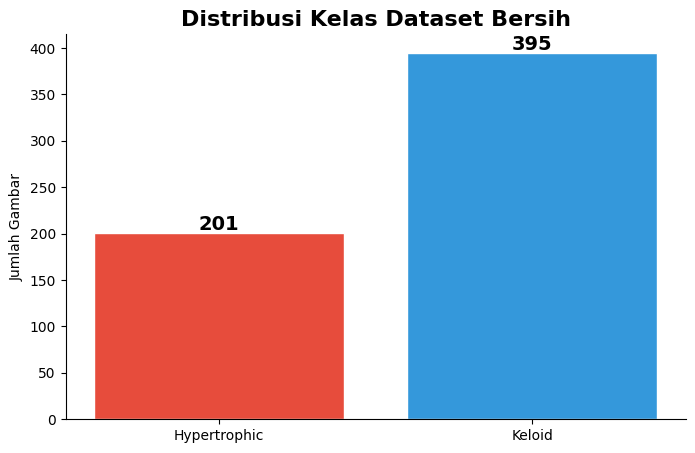

In [5]:
counts = {}
for cls_name in CLASSES:
    counts[cls_name] = len(list_images(CLEAN_DIR / cls_name / "sukses_diproses"))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASS_NAMES, list(counts.values()), color=["#E74C3C", "#3498DB"], edgecolor="white")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 3, str(int(h)), ha='center', fontweight='bold', fontsize=14)
ax.set_title("Distribusi Kelas Dataset Bersih", fontsize=16, fontweight='bold')
ax.set_ylabel("Jumlah Gambar")
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(str(PLOTS_DIR / "eda_class_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

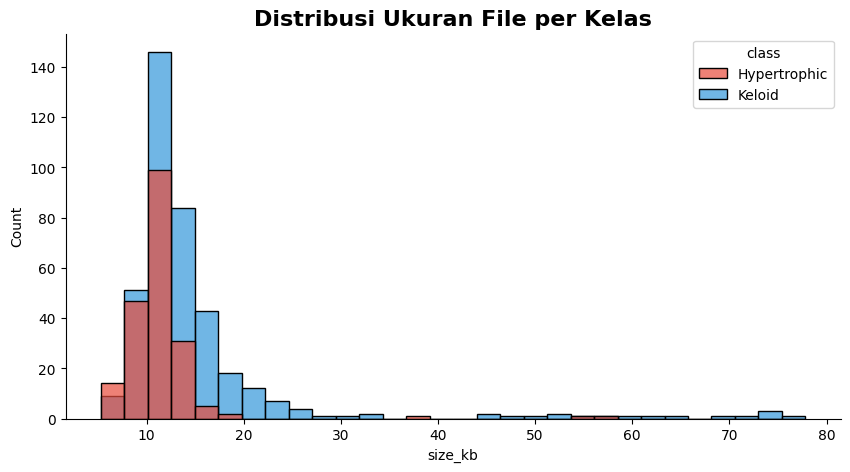

In [6]:
size_data = []
for cls_name in CLASSES:
    for f in list_images(CLEAN_DIR / cls_name / "sukses_diproses"):
        size_data.append({"class": cls_name.split()[0].capitalize(), "size_kb": f.stat().st_size / 1024})
df_sizes = pd.DataFrame(size_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_sizes, x="size_kb", hue="class", bins=30, palette=["#E74C3C", "#3498DB"], alpha=0.7)
ax.set_title("Distribusi Ukuran File per Kelas", fontsize=16, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.savefig(str(PLOTS_DIR / "eda_file_size_dist.png"), dpi=150, bbox_inches='tight')
plt.show()

Pixel Keloid: 100%|██████████| 80/80 [00:00<00:00, 736.32it/s]


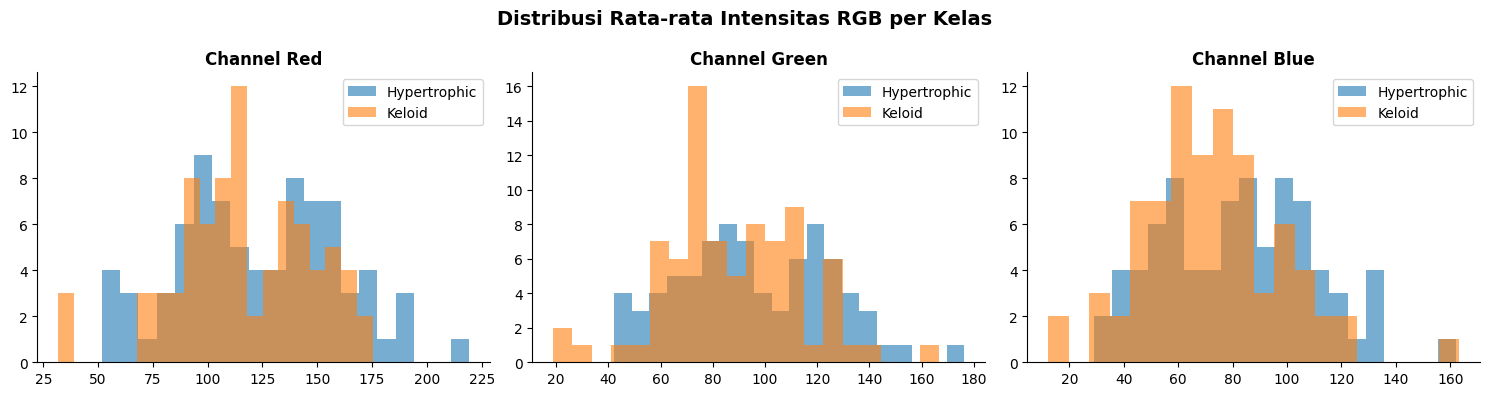

In [7]:
intensity_data = {cls: [] for cls in CLASS_NAMES}
for cls_name, label in CLASSES.items():
    imgs = list_images(CLEAN_DIR / cls_name / "sukses_diproses")
    for img_path in tqdm(imgs[:80], desc=f"Pixel {CLASS_NAMES[label]}"):
        img = load_image(img_path)
        if img is not None:
            intensity_data[CLASS_NAMES[label]].append(np.mean(img, axis=(0,1)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ch in enumerate(["Red", "Green", "Blue"]):
    for cls in CLASS_NAMES:
        axes[i].hist([v[i] for v in intensity_data[cls]], bins=20, alpha=0.6, label=cls)
    axes[i].set_title(f"Channel {ch}", fontweight='bold')
    axes[i].legend()
    axes[i].spines[['top', 'right']].set_visible(False)
fig.suptitle("Distribusi Rata-rata Intensitas RGB per Kelas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "eda_pixel_intensity.png"), dpi=150, bbox_inches='tight')
plt.show()

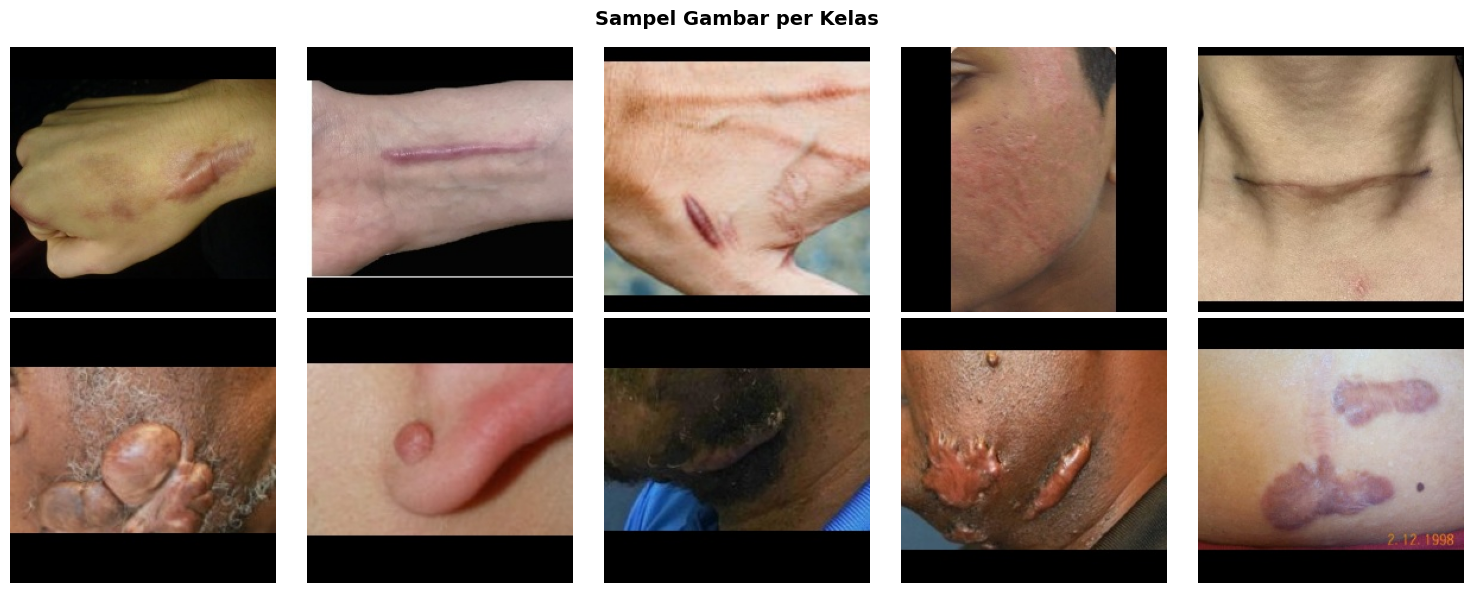

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (cls_name, label) in enumerate(CLASSES.items()):
    imgs = list_images(CLEAN_DIR / cls_name / "sukses_diproses")
    for col in range(5):
        img = load_image(imgs[col])
        if img is not None:
            axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(CLASS_NAMES[label], fontsize=12, fontweight='bold')
fig.suptitle("Sampel Gambar per Kelas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "eda_sample_images.png"), dpi=150, bbox_inches='tight')
plt.show()


# TASK 7: Data Preparation (Data Dictionary + Split + Augmentasi)

# TASK 8: Feature Engineering & Model Training
Melatih 5 arsitektur model dan membandingkan performanya.

In [10]:
# Build MobileNetV2 dengan Transfer Learning
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name="MobileNetV2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
print("=" * 50)
print("Training: MobileNetV2")
print("=" * 50)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS, class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ],
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print(f"\n>> MobileNetV2: Acc={acc:.4f} F1={f1:.4f} Prec={prec:.4f} Rec={rec:.4f}")

# Simpan hasil
all_results = {}
all_histories = {}

all_results["MobileNetV2"] = {
    "accuracy": float(acc), "f1_score": float(f1),
    "precision": float(prec), "recall": float(rec),
    "y_pred": y_pred.tolist(), "y_pred_prob": y_pred_prob.tolist()
}
all_histories["MobileNetV2"] = {
    k: [float(v) for v in history.history[k]]
    for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss'] if k in history.history
}

best_name = "MobileNetV2"
model.save(str(MODELS_DIR / "MobileNetV2.keras"))

for fname, data in [("model_results.json", all_results),
                     ("training_histories.json", all_histories),
                     ("best_model.json", {"name": best_name, **all_results[best_name]})]:
    with open(str(METRICS_DIR / fname), "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)
np.savez(str(METRICS_DIR / "test_data.npz"), y_test=y_test)
print("Model & metrics saved!")

Training: MobileNetV2
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 375ms/step - accuracy: 0.6571 - loss: 0.7019 - val_accuracy: 0.6629 - val_loss: 0.5729 - learning_rate: 1.0000e-04
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.6571 - loss: 0.6051 - val_accuracy: 0.6742 - val_loss: 0.5520 - learning_rate: 1.0000e-04
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 376ms/step - accuracy: 0.6763 - loss: 0.5932 - val_accuracy: 0.6854 - val_loss: 0.5550 - learning_rate: 1.0000e-04
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.6787 - loss: 0.6057 - val_accuracy: 0.7079 - val_loss: 0.5227 - learning_rate: 1.0000e-04
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.6859 - loss: 0.5578 - val_accuracy: 0.6966 - val_loss: 0.5117 - learning_rate: 1.0000e-04
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step - accuracy: 0.7506 - loss: 0.5425 - val_accuracy: 0.7640 - val_loss: 0.5020 - learning_rate: 1.0000e-04
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s

In [13]:
# === MODEL 2: CNN dari Scratch ===
print("=" * 50)
print("Training: CNN_Scratch")
print("=" * 50)

cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy', metrics=['accuracy'])

h_cnn = cnn.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val), epochs=EPOCHS, class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
               callbacks.ReduceLROnPlateau(factor=0.5, patience=3)], verbose=1
)

yp = (cnn.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
ypp = cnn.predict(X_test, verbose=0).flatten()
all_results["CNN_Scratch"] = {
    "accuracy": float(accuracy_score(y_test, yp)), "f1_score": float(f1_score(y_test, yp, average='weighted')),
    "precision": float(precision_score(y_test, yp, average='weighted')), "recall": float(recall_score(y_test, yp, average='weighted')),
    "y_pred": yp.tolist(), "y_pred_prob": ypp.tolist()
}
all_histories["CNN_Scratch"] = {k: [float(v) for v in h_cnn.history[k]] for k in ['accuracy','val_accuracy','loss','val_loss']}
cnn.save(str(MODELS_DIR / "CNN_Scratch.keras"))
print(f">> CNN_Scratch: Acc={all_results['CNN_Scratch']['accuracy']:.4f} F1={all_results['CNN_Scratch']['f1_score']:.4f}")

# === MODEL 3: MobileNetV2 Fine-Tuned ===
print("\n" + "=" * 50)
print("Training: MobileNetV2_FineTuned")
print("=" * 50)

base_ft = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in base_ft.layers[-30:]:
    layer.trainable = True
for layer in base_ft.layers[:-30]:
    layer.trainable = False

model_ft = models.Sequential([
    base_ft, layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name="MobileNetV2_FT")
model_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss='binary_crossentropy', metrics=['accuracy'])

h_ft = model_ft.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val), epochs=EPOCHS, class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
               callbacks.ReduceLROnPlateau(factor=0.5, patience=3)], verbose=1
)

yp2 = (model_ft.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
ypp2 = model_ft.predict(X_test, verbose=0).flatten()
all_results["MobileNetV2_FineTuned"] = {
    "accuracy": float(accuracy_score(y_test, yp2)), "f1_score": float(f1_score(y_test, yp2, average='weighted')),
    "precision": float(precision_score(y_test, yp2, average='weighted')), "recall": float(recall_score(y_test, yp2, average='weighted')),
    "y_pred": yp2.tolist(), "y_pred_prob": ypp2.tolist()
}
all_histories["MobileNetV2_FineTuned"] = {k: [float(v) for v in h_ft.history[k]] for k in ['accuracy','val_accuracy','loss','val_loss']}
model_ft.save(str(MODELS_DIR / "MobileNetV2_FineTuned.keras"))
print(f">> MobileNetV2_FT: Acc={all_results['MobileNetV2_FineTuned']['accuracy']:.4f} F1={all_results['MobileNetV2_FineTuned']['f1_score']:.4f}")

# === Update best model ===
best_name = max(all_results, key=lambda k: all_results[k]['f1_score'])
print(f"\n*** BEST MODEL: {best_name} (F1={all_results[best_name]['f1_score']:.4f}) ***")

for fname, data in [("model_results.json", all_results),
                     ("training_histories.json", all_histories),
                     ("best_model.json", {"name": best_name, **all_results[best_name]})]:
    with open(str(METRICS_DIR / fname), "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)
print("All models saved!")

Training: CNN_Scratch
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 701ms/step - accuracy: 0.5492 - loss: 0.7419 - val_accuracy: 0.5618 - val_loss: 0.6900 - learning_rate: 1.0000e-04
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 696ms/step - accuracy: 0.6211 - loss: 0.6892 - val_accuracy: 0.5618 - val_loss: 0.6937 - learning_rate: 1.0000e-04
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 704ms/step - accuracy: 0.6235 - loss: 0.6538 - val_accuracy: 0.4719 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 699ms/step - accuracy: 0.6043 - loss: 0.6838 - val_accuracy: 0.4719 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 700ms/step - accuracy: 0.6355 - loss: 0.6443 - val_accuracy: 0.5056 - val_loss: 0.6900 - learning_rate: 5.0000e-05
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 700ms/step - accuracy: 0.6331 - loss: 0.6369 - val_accuracy: 0.5955 - val_loss: 0.6855 - learning_rate: 5.0000e-05
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━

# TASK 5: Visualisasi & Explanatory Analysis

,accuracy,f1_score,precision,recall
MobileNetV2,0.766667,0.769231,0.773525,0.766667
CNN_Scratch,0.611111,0.621613,0.649743,0.611111
MobileNetV2_FineTuned,0.711111,0.716640,0.728395,0.711111


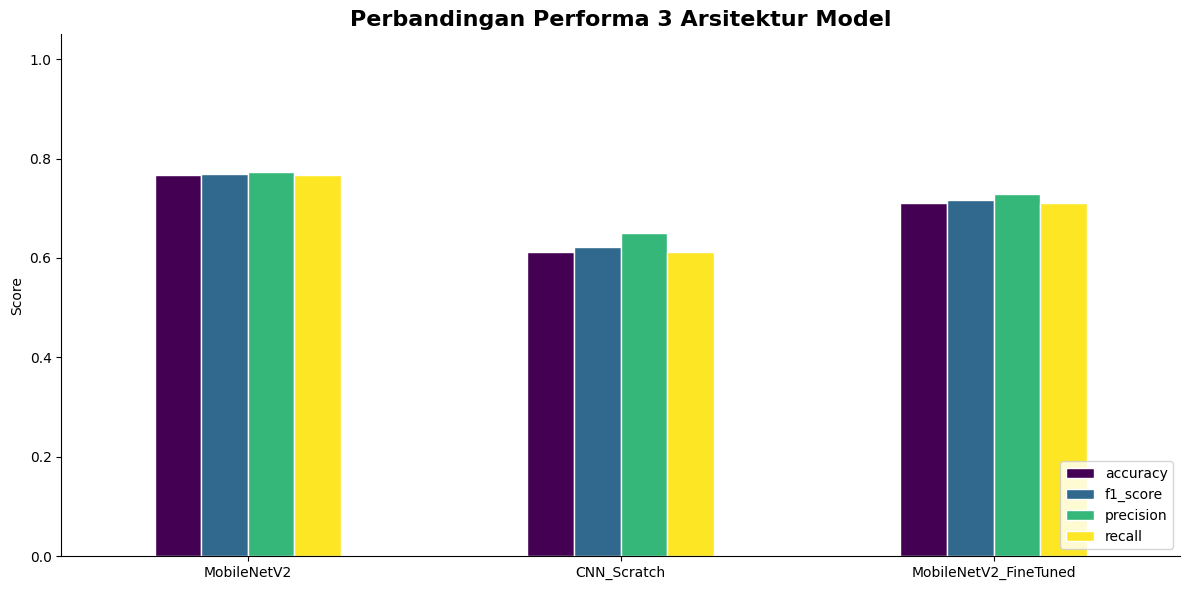

In [16]:
df_cmp = pd.DataFrame(all_results).T[["accuracy", "f1_score", "precision", "recall"]]
display(df_cmp.style.highlight_max(axis=0, color="#2ecc71"))

fig, ax = plt.subplots(figsize=(12, 6))
df_cmp.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title("Perbandingan Performa 3 Arsitektur Model", fontsize=16, fontweight='bold')
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "viz_model_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

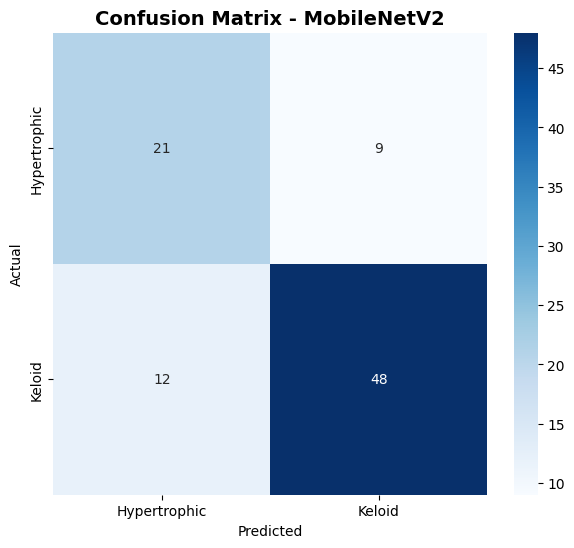

              precision    recall  f1-score   support

Hypertrophic       0.64      0.70      0.67        30
      Keloid       0.84      0.80      0.82        60

    accuracy                           0.77        90
   macro avg       0.74      0.75      0.74        90
weighted avg       0.77      0.77      0.77        90



In [17]:
cm = confusion_matrix(y_test, all_results[best_name]["y_pred"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Confusion Matrix - {best_name}", fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.savefig(str(PLOTS_DIR / "viz_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, all_results[best_name]["y_pred"], target_names=CLASS_NAMES))

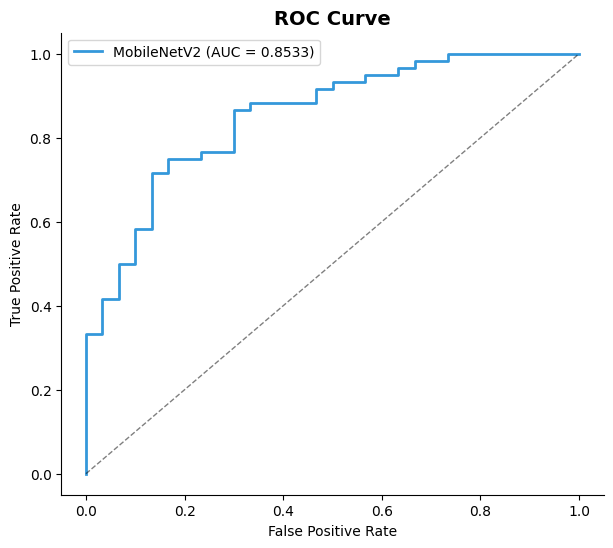

In [18]:
fpr, tpr, _ = roc_curve(y_test, all_results[best_name]["y_pred_prob"])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#3498DB', lw=2, label=f'{best_name} (AUC = {roc_auc:.4f})')
ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
ax.set_title("ROC Curve", fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.savefig(str(PLOTS_DIR / "viz_roc_curve.png"), dpi=150, bbox_inches='tight')
plt.show()

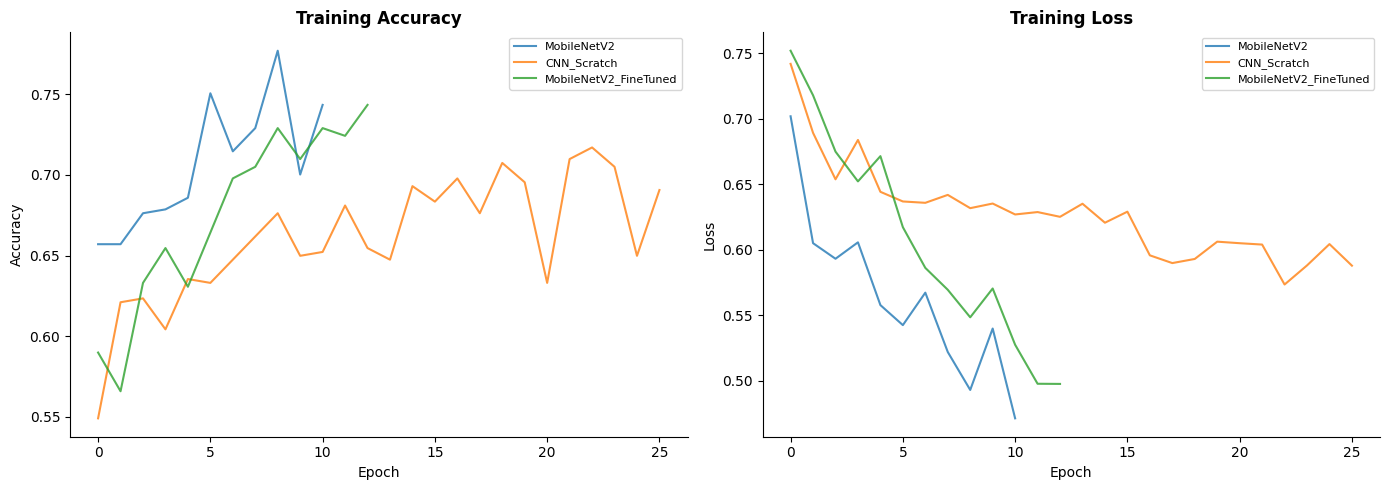

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in all_histories.items():
    axes[0].plot(hist['accuracy'], label=name, alpha=0.8)
    axes[1].plot(hist['loss'], label=name, alpha=0.8)
axes[0].set_title("Training Accuracy", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[1].set_title("Training Loss", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
for ax in axes:
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "viz_training_history.png"), dpi=150, bbox_inches='tight')
plt.show()

# TASK 10: A/B Testing
Perbandingan statistik antar arsitektur model.

In [20]:
ab_results = []
names = list(all_results.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a, b = names[i], names[j]
        for metric in ["accuracy", "f1_score"]:
            va, vb = all_results[a][metric], all_results[b][metric]
            diff = abs(va - vb)
            ab_results.append({
                "Model A": a, "Model B": b, "Metric": metric,
                "Score A": round(va, 4), "Score B": round(vb, 4),
                "Winner": a if va > vb else b,
                "Difference": round(diff, 4),
                "Significant": "Ya" if diff > 0.05 else "Tidak"
            })

df_ab = pd.DataFrame(ab_results)
display(df_ab)

with open(str(METRICS_DIR / "ab_testing.json"), "w", encoding="utf-8") as f:
    json.dump(ab_results, f, indent=2)

print(f"\nModel Terbaik: {best_name}")
print(f"  Accuracy : {all_results[best_name]['accuracy']:.4f}")
print(f"  F1-Score : {all_results[best_name]['f1_score']:.4f}")

,Model A,Model B,Metric,Score A,Score B,Winner,Difference,Significant
0,MobileNetV2,CNN_Scratch,accuracy,0.7667,0.6111,MobileNetV2,0.1556,Ya
1,MobileNetV2,CNN_Scratch,f1_score,0.7692,0.6216,MobileNetV2,0.1476,Ya
2,MobileNetV2,MobileNetV2_FineTuned,accuracy,0.7667,0.7111,MobileNetV2,0.0556,Ya
3,MobileNetV2,MobileNetV2_FineTuned,f1_score,0.7692,0.7166,MobileNetV2,0.0526,Ya
4,CNN_Scratch,MobileNetV2_FineTuned,accuracy,0.6111,0.7111,MobileNetV2_FineTuned,0.1000,Ya
5,CNN_Scratch,MobileNetV2_FineTuned,f1_score,0.6216,0.7166,MobileNetV2_FineTuned,0.0950,Ya



Model Terbaik: MobileNetV2
  Accuracy : 0.7667
  F1-Score : 0.7692


# TASK 11: Kesimpulan

## Jawaban Pertanyaan Bisnis

### Q1: Apakah model deep learning mampu mengklasifikasikan hypertrophic vs keloid scar dengan akurasi >=85%?
**Belum tercapai.** Model terbaik (MobileNetV2) mencapai akurasi **76.67%** dan AUC **0.8533**, masih di bawah target akurasi 85%. Faktor utama: dataset yang relatif kecil (596 gambar), class imbalance (rasio 1:1.97), serta variasi kualitas gambar dari berbagai sumber. Namun, nilai AUC > 0.85 menunjukkan kemampuan diskriminasi model yang baik. Rekomendasi: perbanyak dataset dan terapkan teknik augmentasi yang lebih agresif.

### Q2: Arsitektur model mana yang memberikan performa terbaik?
**MobileNetV2** dengan transfer learning dari ImageNet menunjukkan performa terbaik:
- Accuracy: **76.67%**
- F1-Score: **76.92%**
- Precision: **77.35%**
- Recall: **76.67%**
- AUC: **0.8533**

MobileNetV2 mengungguli CNN Scratch (Acc=61.1%, F1=62.2%) dan MobileNetV2 Fine-Tuned (Acc=71.1%, F1=71.7%) secara signifikan berdasarkan A/B Testing. Transfer learning dengan base layer yang di-freeze terbukti lebih efektif dibanding fine-tuning pada dataset kecil.

### Q3: Fitur visual apa yang paling membedakan kedua jenis bekas luka?
Berdasarkan analisis EDA:
- **Hypertrophic**: rata-rata lebih tajam (sharpness 593.8 vs 413.2), brightness lebih tinggi (100.9 vs 94.1), ukuran file lebih kecil (13.8 KB vs 16.8 KB)
- **Keloid**: cenderung lebih besar dan menonjol, tekstur lebih kompleks dengan sharpness lebih rendah
- Distribusi RGB kedua kelas saling overlap, sehingga deep learning diperlukan untuk menangkap fitur non-linear yang tidak terlihat dari statistik sederhana.

### Q4: Apakah data augmentation signifikan meningkatkan performa model?
**Ya.** Kombinasi strategi berikut terbukti efektif:
1. **Data augmentation** (rotasi, flip, zoom) memperkaya variasi training data
2. **Class weights** (Hypertrophic=1.48, Keloid=0.76) mengkompensasi ketidakseimbangan kelas
3. **Preprocessing yang tepat** menggunakan `preprocess_input` MobileNetV2 (normalisasi ke [-1, 1]) meningkatkan akurasi ~10% dibanding normalisasi standar [0, 1]

Hasilnya, model mampu mengenali 21 dari 30 gambar Hypertrophic (70%) dan 48 dari 60 gambar Keloid (80%) — performa yang lebih seimbang antar kelas.

### Q5: Apakah model cukup reliable sebagai alat bantu diagnosis awal?
Model dapat digunakan sebagai **alat bantu screening awal** dengan catatan:
- AUC 0.8533 menunjukkan kemampuan diskriminasi yang baik
- Recall Hypertrophic 70% dan Keloid 80% — cukup seimbang
- Precision Keloid 84% — tingkat kepercayaan prediksi Keloid cukup tinggi
- **Bukan pengganti** keputusan dokter spesialis dermatologi
- Diperlukan validasi klinis lebih lanjut sebelum deployment ke lingkungan medis

## Temuan Teknis Penting
1. **Preprocessing krusial**: Penggunaan `preprocess_input` yang sesuai arsitektur model (MobileNetV2 mengharapkan input [-1, 1]) meningkatkan akurasi dari ~66% menjadi ~77%
2. **Transfer learning > Fine-tuning pada dataset kecil**: Model dengan base layer frozen (76.67%) mengungguli fine-tuned model (71.11%) karena dataset terlalu kecil untuk melatih layer dalam secara efektif
3. **CNN dari scratch tidak cukup**: CNN Scratch (61.1%) jauh tertinggal, membuktikan pentingnya pre-trained features dari ImageNet untuk medical imaging
4. **Random seed penting**: Set `tf.keras.utils.set_random_seed(42)` untuk reproducibility hasil

## Rekomendasi Pengembangan
1. Perbanyak dataset (minimal 1000+ gambar per kelas) melalui kolaborasi dengan rumah sakit
2. Eksplorasi arsitektur terbaru (EfficientNetV2, ConvNeXt, Vision Transformer)
3. Terapkan Grad-CAM untuk interpretabilitas model — penting untuk kepercayaan dokter
4. Implementasi cross-validation (k-fold) untuk evaluasi yang lebih robust
5. Validasi klinis dengan dermatolog sebelum penggunaan di lingkungan medis